In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from datasets import load_dataset





C:\Users\VICTUS\anaconda3\envs\gpu_room\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
raw_dataset = load_dataset("parquet", data_files={
    "train": "hf://datasets/daily_dialog@refs/convert/parquet/default/train/0000.parquet",
    "validation": "hf://datasets/daily_dialog@refs/convert/parquet/default/validation/0000.parquet",
    "test": "hf://datasets/daily_dialog@refs/convert/parquet/default/test/0000.parquet"
})

In [3]:
raw_dataset['train'][1]


{'dialog': ['Can you do push-ups ? ',
  " Of course I can . It's a piece of cake ! Believe it or not , I can do 30 push-ups a minute . ",
  " Really ? I think that's impossible ! ",
  ' You mean 30 push-ups ? ',
  ' Yeah ! ',
  " It's easy . If you do exercise everyday , you can make it , too . "],
 'act': [2, 1, 2, 2, 1, 1],
 'emotion': [0, 0, 6, 0, 0, 0]}

In [4]:
# Check a sample conversation from your new train split
sample = raw_dataset['train'][0]
print("Dialogue Turns:")
for i, turn in enumerate(sample['dialog']):
    print(f"  Turn {i+1}: {turn}")

print("\nAct Labels (Topic Context):", sample['act'])
print("Emotion Labels:", sample['emotion'])

Dialogue Turns:
  Turn 1: Say , Jim , how about going for a few beers after dinner ? 
  Turn 2:  You know that is tempting but is really not good for our fitness . 
  Turn 3:  What do you mean ? It will help us to relax . 
  Turn 4:  Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ? 
  Turn 5:  I guess you are right.But what shall we do ? I don't feel like sitting at home . 
  Turn 6:  I suggest a walk over to the gym where we can play singsong and meet some of our friends . 
  Turn 7:  That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them . 
  Turn 8:  Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too . 
  Turn 9:  Good.Let ' s go now . 
  Turn 10:  All right . 

Act Labels (Topic Context): [3, 4, 2, 2, 2, 3, 4, 1, 3, 4]
Emotion Labels: [0, 0, 0, 0, 0, 0, 4, 4, 4, 4]


In [4]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Flatten your DailyDialog data into a simple list of sentences
all_sentences = [turn for example in raw_dataset['train'] for turn in example['dialog']]

# Initialize the Keras Tokenizer layer
vectorize_layer = TextVectorization(
    max_tokens=15000,
    standardize='lower_and_strip_punctuation', # Does cleaning automatically
    split='whitespace',                        # Splits words by spaces
    output_mode='int'                          # Outputs integer indices
)

# Adapt learns the vocabulary mapping (creates word-to-index under the hood)
vectorize_layer.adapt(all_sentences)

In [6]:
len(all_sentences)


87170

In [7]:
all_sentences[:3]

['Say , Jim , how about going for a few beers after dinner ? ',
 ' You know that is tempting but is really not good for our fitness . ',
 ' What do you mean ? It will help us to relax . ']

In [8]:
vocabulary = vectorize_layer.get_vocabulary()

print("Vocabulary size:", len(vocabulary))
print("First 5 tokens in Keras mapping:", vocabulary[:7])

Vocabulary size: 15000
First 5 tokens in Keras mapping: ['', '[UNK]', 'you', 'i', 'the', 'to', 'a']


In [9]:
word_to_find = "you"
if word_to_find in vocabulary:
    word_idx = vocabulary.index(word_to_find)
    print(f"The index for '{word_to_find}' is: {word_idx}")

The index for 'you' is: 2


In [10]:
vectorize_layer(["how are you doing","Hi what about you"])

<tf.Tensor: shape=(2, 4), dtype=int64, numpy=
array([[ 31,  17,   2, 207],
       [198,  19,  33,   2]], dtype=int64)>

In [5]:
vectorised_sentences=vectorize_layer(all_sentences)

In [6]:
vectorised_sentences.shape

TensorShape([87170, 254])

In [14]:
import numpy as np

# 1. Flatten the entire 2D tensor into a 1D array and remove all zeros instantly
flat_tokens = vectorised_sentences.numpy().flatten()
clean_tokens = flat_tokens[flat_tokens != 0]

print(f"Total non-padded words to process: {len(clean_tokens)}")

# 2. Use a vector slice technique to build your inputs and targets without loops
sequence_length = 8
total_windows = len(clean_tokens) - sequence_length

# Create index matrices
idx = np.arange(sequence_length) + np.arange(total_windows)[:, None]

# Extract arrays
X_array = clean_tokens[idx]
y_array = clean_tokens[sequence_length : sequence_length + total_windows]

print(f"Instantly generated X shape: {X_array.shape}")
print(f"Instantly generated y shape: {y_array.shape}")

Total non-padded words to process: 996311
Instantly generated X shape: (996303, 8)
Instantly generated y shape: (996303,)


In [15]:
X_array

array([[ 151,  947,   31, ...,   15,    6,  205],
       [ 947,   31,   33, ...,    6,  205, 3376],
       [  31,   33,   73, ...,  205, 3376,  160],
       ...,
       [   3,   14,    4, ...,  224,   88,   48],
       [  14,    4,  194, ...,   88,   48,   24],
       [   4,  194,   66, ...,   48,   24,    6]], dtype=int64)

In [16]:
y_array

array([3376,  160,  295, ...,   24,    6,  479], dtype=int64)

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 1. Create the high-speed GPU pipeline using your arrays
batch_size = 512
train_dataset = tf.data.Dataset.from_tensor_slices((X_array, y_array))
train_dataset = train_dataset.shuffle(buffer_size=50000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 2. Get your exact vocabulary size from the vectorize layer
vocab_size = len(vectorize_layer.get_vocabulary())
sequence_length = 8
embedding_dim = 256
hidden_units = 512

# 3. Define the Network
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length),
    
    LSTM(hidden_units, return_sequences=True),
    Dropout(0.2),
    
    LSTM(hidden_units),
    Dropout(0.2),
    
    Dense(vocab_size, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [18]:
# 4. Kick off the training loop!
epochs = 15
history = model.fit(train_dataset, epochs=epochs)

Epoch 1/15
1946/1946 [==============================] - 148s 58ms/step - loss: 5.8651 - accuracy: 0.0943
Epoch 2/15
1946/1946 [==============================] - 127s 65ms/step - loss: 5.1058 - accuracy: 0.1579
Epoch 3/15
1946/1946 [==============================] - 114s 58ms/step - loss: 4.8185 - accuracy: 0.1774
Epoch 4/15
1946/1946 [==============================] - 104s 53ms/step - loss: 4.6158 - accuracy: 0.1892
Epoch 5/15
1946/1946 [==============================] - 59s 30ms/step - loss: 4.4472 - accuracy: 0.1985
Epoch 6/15
1946/1946 [==============================] - 58s 30ms/step - loss: 4.3038 - accuracy: 0.2052
Epoch 7/15
1946/1946 [==============================] - 59s 30ms/step - loss: 4.1776 - accuracy: 0.2128
Epoch 8/15
1946/1946 [==============================] - 59s 30ms/step - loss: 4.0659 - accuracy: 0.2205
Epoch 9/15
1946/1946 [==============================] - 58s 30ms/step - loss: 3.9652 - accuracy: 0.2281
Epoch 10/15
1946/1946 [==============================] - 59s

In [29]:
import numpy as np

def generate_text_stream(seed_phrase, words_to_predict=4, temperature=0.3):
    """
    Takes a starter seed phrase, predicts the next word, appends it, 
    and loops to generate a full conversational line of text.
    """
    generated_text = seed_phrase
    print(f"Seed Prompt: '{seed_phrase}'")
    print(f"Generated Chat: {seed_phrase}", end=" ")

    for _ in range(words_to_predict):
        # 1. Map raw input text directly to integer tokens via your adapted layer
        tokens = vectorize_layer([generated_text]).numpy()[0]
        
        # Remove trailing/leading padding from the vectorization matrix
        clean_tokens = tokens[tokens != 0]
        
        # 2. Enforce structural sequence constraint of exactly 8 elements
        if len(clean_tokens) < 8:
            # Pre-pad with zeros if the sentence is shorter than context window
            padded_input = np.pad(clean_tokens, (8 - len(clean_tokens), 0), 'constant')
        else:
            # Truncate to take only the last 8 words if context length is exceeded
            padded_input = clean_tokens[-8:]
            
        # Reshape to fit model batch dimensions: (1, 8)
        input_tensor = np.array([padded_input])
        
        # 3. Generate predictions
        predictions = model.predict(input_tensor, verbose=0)[0]
        
        # 4. Temperature Sampling (Prevents the model from getting stuck repeating words)
        # 0.6 is a good sweet spot for clean grammar with a bit of variety
        predictions = np.log(predictions + 1e-7) / temperature
        exp_preds = np.exp(predictions)
        predicted_probs = exp_preds / np.sum(exp_preds)
        
        # Sample the next token index based on the calculated probability distribution
        predicted_idx = np.random.choice(len(predicted_probs), p=predicted_probs)
        
        # 5. Reverse map the index back to a string word
        vocabulary = vectorize_layer.get_vocabulary()
        predicted_word = vocabulary[predicted_idx]
        
        # Break execution if blanks or structural flags are generated
        if predicted_word in ["", "[UNK]"]:
            continue
            
        # Append word to history for the next iteration loop pass
        generated_text += " " + predicted_word
        print(predicted_word, end=" ", flush=True)
    print("\n" + "="*50)

In [30]:
generate_text_stream("how are you")
generate_text_stream("what do you want to")
generate_text_stream("i am going to")

Seed Prompt: 'how are you'
Generated Chat: how are you doing i just wanted 
Seed Prompt: 'what do you want to'
Generated Chat: what do you want to eat i want to 
Seed Prompt: 'i am going to'
Generated Chat: i am going to have a good time 


In [31]:
# Save the model in the native Keras format
model.save("daily_dialog_lstm_v1.keras")
print("Model architecture and weights saved successfully!")

Model architecture and weights saved successfully!


In [32]:
import json

# Extract the vocabulary list from your vectorization layer
vocab = vectorize_layer.get_vocabulary()

# Save it as a JSON file so it retains its exact string indexing
with open("vocab_config.json", "w") as f:
    json.dump(vocab, f)

print(f"Vocabulary list saved successfully! (Total words: {len(vocab)})")

Vocabulary list saved successfully! (Total words: 15000)


In [33]:
import numpy as np

# 1. Convert all sentences into sequences of integers
# This returns a padded 2D tensor (Rows = sentences, Columns = words)
vectorized_sentences = vectorize_layer(all_sentences).numpy()

sequence_length = 8
X_sequences = []
y_targets = []

print("Starting sentence-isolated window generation...")

# 2. Slice the matrix row-by-row (Sentence by Sentence)
for encoded_sentence in vectorized_sentences:
    # Filter out trailing zeros caused by padding inside individual short sentences
    # This keeps the sentence completely isolated!
    non_zero_tokens = encoded_sentence[encoded_sentence != 0]
    
    # If the individual sentence doesn't have enough words to fill the window, skip it
    if len(non_zero_tokens) <= sequence_length:
        continue
        
    # Generate the moving window pairs strictly inside THIS sentence
    for i in range(len(non_zero_tokens) - sequence_length):
        X_sequences.append(non_zero_tokens[i : i + sequence_length])
        y_targets.append(non_zero_tokens[i + sequence_length])

# Convert the final clean lists into NumPy arrays for Keras
X_array = np.array(X_sequences)
y_array = np.array(y_targets)

print("\n--- Generation Complete ---")
print(f"Total training windows generated (No Mixing): {X_array.shape[0]}")
print(f"Inputs (X_array) Shape: {X_array.shape}")
print(f"Targets (y_array) Shape: {y_array.shape}")

Starting sentence-isolated window generation...

--- Generation Complete ---
Total training windows generated (No Mixing): 411474
Inputs (X_array) Shape: (411474, 8)
Targets (y_array) Shape: (411474,)


In [34]:
# 1. Rebuild the GPU pipeline with the pure isolated data
batch_size = 512
pure_train_dataset = tf.data.Dataset.from_tensor_slices((X_array, y_array))
pure_train_dataset = pure_train_dataset.shuffle(buffer_size=50000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 2. Reset and recompile your model structure so it trains completely fresh
model_v2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length),
    
    LSTM(hidden_units, return_sequences=True),
    Dropout(0.2),
    
    LSTM(hidden_units),
    Dropout(0.2),
    
    Dense(vocab_size, activation='softmax')
])

model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Fire it up for 15 epochs!
history_v2 = model_v2.fit(pure_train_dataset, epochs=15)

Epoch 1/15
804/804 [==============================] - 29s 29ms/step - loss: 6.4898 - accuracy: 0.0569
Epoch 2/15
804/804 [==============================] - 23s 28ms/step - loss: 5.7011 - accuracy: 0.1159
Epoch 3/15
804/804 [==============================] - 23s 29ms/step - loss: 5.3678 - accuracy: 0.1377
Epoch 4/15
804/804 [==============================] - 23s 28ms/step - loss: 5.1335 - accuracy: 0.1533
Epoch 5/15
804/804 [==============================] - 25s 31ms/step - loss: 4.9397 - accuracy: 0.1641
Epoch 6/15
804/804 [==============================] - 24s 29ms/step - loss: 4.7640 - accuracy: 0.1736
Epoch 7/15
804/804 [==============================] - 25s 31ms/step - loss: 4.5998 - accuracy: 0.1817
Epoch 8/15
804/804 [==============================] - 24s 30ms/step - loss: 4.4440 - accuracy: 0.1899
Epoch 9/15
804/804 [==============================] - 23s 29ms/step - loss: 4.2970 - accuracy: 0.1995
Epoch 10/15
804/804 [==============================] - 23s 29ms/step - loss: 4.159

In [37]:
# 1. Test your original MIXED model (Run 1)
model = model  # or whatever variable holds your first model
print("=== MIXED MODEL RESPONSE ===")
generate_text_stream("how are you", words_to_predict=10)

print("\n" + "#"*40 + "\n")

# 2. Test your new PURE sentence-isolated model (Run 2)
model = model_v2
print("=== PURE ISOLATED MODEL RESPONSE ===")
generate_text_stream("how are you", words_to_predict=10)
generate_text_stream("what are you", words_to_predict=10)

=== MIXED MODEL RESPONSE ===
Seed Prompt: 'how are you'
Generated Chat: how are you going to do for you today i ’ m going 

########################################

=== PURE ISOLATED MODEL RESPONSE ===
Seed Prompt: 'how are you'
Generated Chat: how are you going to do with you today i ’ m sure 
Seed Prompt: 'what are you'
Generated Chat: what are you going to do with the next step in the afternoon 


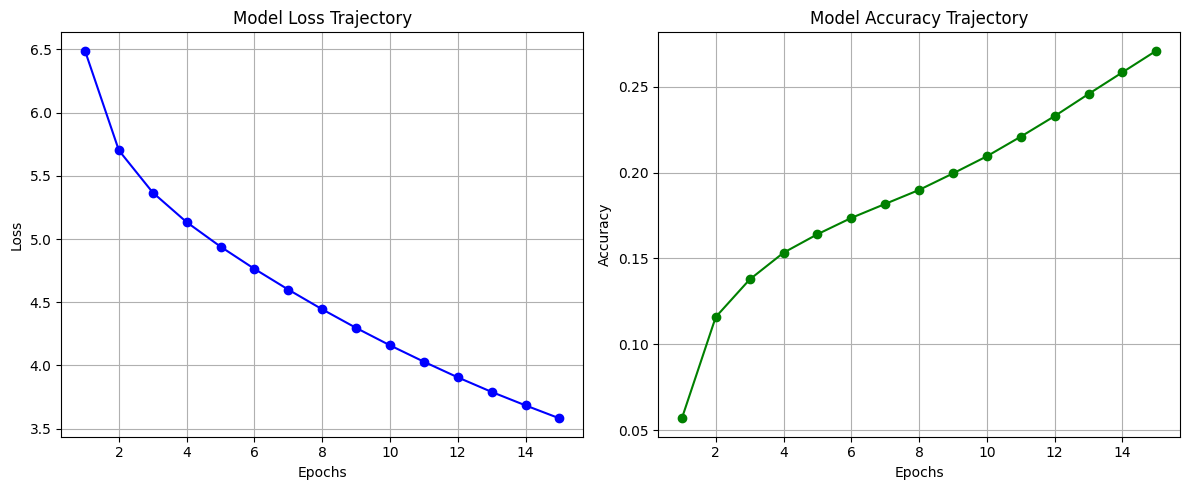

In [38]:
import matplotlib.pyplot as plt

# Extract metrics from the history object
loss = history_v2.history['loss']
accuracy = history_v2.history['accuracy']
epochs_range = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

# Plot 1: Cross-Entropy Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, 'b-o', label='Training Loss')
plt.title('Model Loss Trajectory')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

# Plot 2: Top-1 Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, accuracy, 'g-o', label='Training Accuracy')
plt.title('Model Accuracy Trajectory')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
# Continue training model_v2 for 15 more epochs
history_continued = model_v2.fit(pure_train_dataset, epochs=10)

Epoch 1/10
804/804 [==============================] - 23s 29ms/step - loss: 3.4882 - accuracy: 0.2835
Epoch 2/10
804/804 [==============================] - 24s 30ms/step - loss: 3.3970 - accuracy: 0.2963
Epoch 3/10
804/804 [==============================] - 24s 30ms/step - loss: 3.3089 - accuracy: 0.3088
Epoch 4/10
804/804 [==============================] - 23s 28ms/step - loss: 3.2248 - accuracy: 0.3206
Epoch 5/10
804/804 [==============================] - 25s 31ms/step - loss: 3.1431 - accuracy: 0.3332
Epoch 6/10
804/804 [==============================] - 24s 30ms/step - loss: 3.0659 - accuracy: 0.3454
Epoch 7/10
804/804 [==============================] - 24s 29ms/step - loss: 2.9894 - accuracy: 0.3580
Epoch 8/10
804/804 [==============================] - 24s 29ms/step - loss: 2.9155 - accuracy: 0.3693
Epoch 9/10
804/804 [==============================] - 24s 29ms/step - loss: 2.8420 - accuracy: 0.3811
Epoch 10/10
804/804 [==============================] - 24s 30ms/step - loss: 2.775

In [40]:
# Re-point the global model reference to your freshly trained v2 engine
model = model_v2

print("=== UPGRADED PURE MODEL RESPONSES ===")
generate_text_stream("how are you", words_to_predict=12, temperature=0.5)
generate_text_stream("what are you", words_to_predict=12, temperature=0.5)
generate_text_stream("i am going to", words_to_predict=12, temperature=0.5)

=== UPGRADED PURE MODEL RESPONSES ===
Seed Prompt: 'how are you'
Generated Chat: how are you interested in those in the light belt is a little good thing 
Seed Prompt: 'what are you'
Generated Chat: what are you in the mood for a salesperson ’ s a little ragged about 
Seed Prompt: 'i am going to'
Generated Chat: i am going to be the groomsman and the subway is that right now but i 


In [43]:
# Save the model in the native Keras format
model_v2.save("daily_dialog_lstm_v2.keras")
print("Model architecture and weights saved successfully!")

Model architecture and weights saved successfully!
